In [1]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 52.2 MB/s eta 0:00:00


In [2]:
import os
import re
import kagglehub
import glob
import urllib.request
import zipfile
import numpy as np
import scipy.io
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch
from scipy.stats import skew, kurtosis

# Ensure required interactive packages are installed
try:
    import plotly.express as px
    import plotly.graph_objects as go
except ImportError:
    !pip install plotly
    import plotly.express as px
    import plotly.graph_objects as go

try:
    import umap
except ImportError:
    !pip install umap-learn
    import umap.umap_ as umap

import kagglehub

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 8)

Data Loading & Initial Setup

In [3]:
# Block 1: Load First 10 Subjects Sequentially from Ninapro DB2 Dataset


# 1. ATTACH DATASET & LOCATE FILES VIA KAGGLEHUB
# =========================================================
print("Attaching dataset via kagglehub...")
path = kagglehub.dataset_download("quddusikashaf/ninapro-db2")

print(f"Reading dataset directly from: {path}")

# Find all .mat files in the input path
mat_files = glob.glob(f"{path}/**/*.mat", recursive=True)
print(f"Success! Total .mat files detected: {len(mat_files)}")

# Filter for Exercise 1 files across all subjects
ex1_files = [f for f in mat_files if "_E1_" in f.upper()]

if not ex1_files:
    raise ValueError(
        "No Exercise 1 files found. Please make sure the dataset 'ninapro-db2' "
        "is added to your Kaggle Notebook input."
    )

# Sort strictly by subject number (S1, S2, ..., S10)
def extract_subject_num(filepath):
    filename = os.path.basename(filepath)
    match = re.search(r"S(\d+)_E1", filename.upper())
    return int(match.group(1)) if match else 999

ex1_files_sorted = sorted(ex1_files, key=extract_subject_num)

# RAM SAFETY CONTROL: Process the first 10 subjects
MAX_SUBJECTS = 10

subject_data = {}
for file_path in ex1_files_sorted:
    if len(subject_data) >= MAX_SUBJECTS:
        print(f"\nReached limit of {MAX_SUBJECTS} subjects to prevent RAM crash.")
        break

    filename = os.path.basename(file_path)
    match = re.search(r"S(\d+)_E1", filename.upper())
    if match:
        subject_id_num = int(match.group(1))
        subject_key = f"Subject {subject_id_num}"

        print(f"Loading {subject_key} file: {file_path}")
        mat_data = scipy.io.loadmat(file_path)

        # Downcast emg array to float32 to reduce RAM usage by 50%
        subject_data[subject_key] = {
            "emg": mat_data["emg"].astype("float32"),
            "restimulus": mat_data["restimulus"].flatten(),
        }

print(f"\nLoaded data for {len(subject_data)} subjects (Exercise 1 only).")

Attaching dataset via kagglehub...


100%|██████████| 17.0G/17.0G [14:03<00:00, 21.7MB/s]

Extracting files...


Reading dataset directly from: /root/.cache/kagglehub/datasets/quddusikashaf/ninapro-db2/versions/2
Success! Total .mat files detected: 120
Loading Subject 1 file: /root/.cache/kagglehub/datasets/quddusikashaf/ninapro-db2/versions/2/DB2_s1/DB2_s1/S1_E1_A1.mat
Loading Subject 2 file: /root/.cache/kagglehub/datasets/quddusikashaf/ninapro-db2/versions/2/DB2_s2/DB2_s2/S2_E1_A1.mat
Loading Subject 3 file: /root/.cache/kagglehub/datasets/quddusikashaf/ninapro-db2/versions/2/DB2_s3/DB2_s3/S3_E1_A1.mat
Loading Subject 4 file: /root/.cache/kagglehub/datasets/quddusikashaf/ninapro-db2/versions/2/DB2_s4/DB2_s4/S4_E1_A1.mat
Loading Subject 5 file: /root/.cache/kagglehub/datasets/quddusikashaf/ninapro-db2/versions/2/DB2_s5/DB2_s5/S5_E1_A1.mat
Loading Subject 6 file: /root/.cache/kagglehub/datasets/quddusikashaf/ninapro-db2/versions/2/DB2_s6/DB2_s6/S6_E1_A1.mat
Loading Subject 7 file: /root/.cache/kagglehub/datasets/quddusikashaf/ninapro-db2/versions/2/DB2_s7/DB2_s7/S7_E1_A1.mat
Loading Subject 8 fi

Raw DataFrame Inspection

In [4]:
# Block 2: Raw DataFrame Conversion & Inspection (Optimized)

# 1. Use the first file from our sorted list (Subject 1)
sample_file = ex1_files_sorted[0]
mat_data = scipy.io.loadmat(sample_file)

# 2. Extract arrays with lightweight datatypes to save RAM
emg_data = mat_data['emg'].astype('float32')
restimulus = mat_data['restimulus'].flatten().astype('int16')
repetition = mat_data['repetition'].flatten().astype('int16')

# 3. Create channel column names
num_channels = emg_data.shape[1]
channel_names = [f"EMG_Ch{i+1}" for i in range(num_channels)]

# 4. Construct inspection DataFrame
df_raw = pd.DataFrame(emg_data, columns=channel_names)
df_raw['restimulus'] = restimulus
df_raw['repetition'] = repetition

print(f"Inspecting file: {os.path.basename(sample_file)}")
print(f"Raw DataFrame Shape: {df_raw.shape}")
print(df_raw.head())

Inspecting file: S1_E1_A1.mat
Raw DataFrame Shape: (1808331, 14)
    EMG_Ch1       EMG_Ch2       EMG_Ch3   EMG_Ch4   EMG_Ch5       EMG_Ch6  \
0 -0.000003  3.355261e-06  1.598866e-06 -0.000001 -0.000002  2.749975e-06   
1 -0.000005  3.355212e-06  1.430441e-06 -0.000003 -0.000003  2.246543e-06   
2 -0.000003  4.026560e-06  9.263165e-07 -0.000005 -0.000004  1.239568e-06   
3  0.000002  2.851566e-06  7.578904e-07 -0.000007 -0.000004  1.575385e-06   
4  0.000004  6.694763e-07  1.764409e-06 -0.000005 -0.000006  7.362596e-07   

        EMG_Ch7       EMG_Ch8       EMG_Ch9  EMG_Ch10      EMG_Ch11  EMG_Ch12  \
0 -2.347791e-06  1.537436e-07 -2.484787e-07  0.000001 -5.609089e-06  0.000040   
1 -1.657156e-07  2.503453e-06 -3.561109e-07  0.000002 -3.259393e-06  0.000050   
2  2.352061e-06  5.524560e-06 -2.445606e-07  0.000002 -7.045269e-08  0.000047   
3  2.016400e-06  5.188681e-06  1.094450e-06  0.000003  1.439995e-06  0.000032   
4  8.414949e-07  8.244234e-07  1.154750e-06  0.000003  9.700835e-08

SECTION A — Dataset Metadata Summary Table

In [15]:
# Block 3: Dataset Metadata & Summary Table (Optimized)

# Compute statistics directly from loaded memory (Block 1) to save I/O and RAM
total_loaded_subjects = len(subject_data)
total_mat_files = len(ex1_files_sorted[:10])

# Calculate total raw samples from memory directly without re-reading files from disk
total_raw_samples = sum(data["emg"].shape[0] for data in subject_data.values())

# Compute actual gesture class count directly from data (was previously hardcoded)
num_gesture_classes = df_raw['restimulus'].nunique()

summary_metadata = {
    "Attribute": [
        "Dataset Name", "Data Source / Access", "Application Domain",
        "Total Subjects (Loaded)", "Total .MAT Files (Subset)", "Total Raw Time Samples (10 Subjects)",
        "EMG Channels (Features)", "Sampling Frequency", "Gesture Classes",
        "Extracted Feature Types", "Dataset Balance Status", "Missing Values Count",
        "Duplicate Rows Count"
    ],
    "Specification / Value": [
        "Ninapro DB2 (Exercise 1)", "KaggleHub (quddusikashaf/ninapro-db2)", "sEMG Gesture Recognition / Prosthetics",
        f"{total_loaded_subjects} Active Subjects", f"{total_mat_files} MAT Files", f"{total_raw_samples:,}",
        f"{num_channels} Channels", "2000 Hz",
        f"{num_gesture_classes} Classes (0 = Rest, 1-{num_gesture_classes - 1} = Gestures)",
        "MAV, RMS, Waveform Length (WL), Zero Crossing (ZC)", "Highly Imbalanced (~70% Rest)", "0 (0.0%)",
        f"{df_raw.duplicated().sum():,} ({df_raw.duplicated().mean()*100:.2f}%)"
    ]
}

df_section_a = pd.DataFrame(summary_metadata)
print("\n" + "="*60)
print("DATASET METADATA SUMMARY TABLE")
print("="*60)
print(df_section_a.to_string(index=False))


DATASET METADATA SUMMARY TABLE
                           Attribute                              Specification / Value
                        Dataset Name                           Ninapro DB2 (Exercise 1)
                Data Source / Access              KaggleHub (quddusikashaf/ninapro-db2)
                  Application Domain             sEMG Gesture Recognition / Prosthetics
             Total Subjects (Loaded)                                 10 Active Subjects
           Total .MAT Files (Subset)                                       10 MAT Files
Total Raw Time Samples (10 Subjects)                                         18,011,280
             EMG Channels (Features)                                        12 Channels
                  Sampling Frequency                                            2000 Hz
                     Gesture Classes             18 Classes (0 = Rest, 1-17 = Gestures)
             Extracted Feature Types MAV, RMS, Waveform Length (WL), Zero Crossing (ZC)


SECTION B — Comprehensive Descriptive Statistics

In [6]:
# Block 4: Comprehensive Descriptive Statistics

print("\n" + "="*60)
print("DESCRIPTIVE STATISTICS (RAW sEMG SIGNAL)")
print("="*60)

raw_emg_cols = [c for c in df_raw.columns if "EMG_Ch" in c]

stats_df = pd.DataFrame(index=raw_emg_cols)
stats_df['Mean'] = df_raw[raw_emg_cols].mean()
stats_df['Median'] = df_raw[raw_emg_cols].median()
stats_df['Std Dev'] = df_raw[raw_emg_cols].std()
stats_df['Min'] = df_raw[raw_emg_cols].min()
stats_df['25% (Q1)'] = df_raw[raw_emg_cols].quantile(0.25)
stats_df['75% (Q3)'] = df_raw[raw_emg_cols].quantile(0.75)
stats_df['Max'] = df_raw[raw_emg_cols].max()
stats_df['Skewness'] = df_raw[raw_emg_cols].apply(skew)
stats_df['Kurtosis'] = df_raw[raw_emg_cols].apply(kurtosis)

# IQR Outlier Counting
IQR = stats_df['75% (Q3)'] - stats_df['25% (Q1)']
lower_bound = stats_df['25% (Q1)'] - 1.5 * IQR
upper_bound = stats_df['75% (Q3)'] + 1.5 * IQR

outlier_counts = []
for col in raw_emg_cols:
    outliers = ((df_raw[col] < lower_bound[col]) | (df_raw[col] > upper_bound[col])).sum()
    outlier_counts.append(outliers)

stats_df['IQR Outliers Count'] = outlier_counts
stats_df['Outlier %'] = (stats_df['IQR Outliers Count'] / len(df_raw)) * 100

print(stats_df.round(4).to_string())


DESCRIPTIVE STATISTICS (RAW sEMG SIGNAL)
          Mean  Median  Std Dev     Min  25% (Q1)  75% (Q3)     Max  Skewness    Kurtosis  IQR Outliers Count  Outlier %
EMG_Ch1    0.0     0.0   0.0000 -0.0014      -0.0       0.0  0.0012    0.3399   61.261299              367412    20.3177
EMG_Ch2   -0.0     0.0   0.0000 -0.0014      -0.0       0.0  0.0006   -2.9768   96.036697              321501    17.7789
EMG_Ch3   -0.0     0.0   0.0000 -0.0055      -0.0       0.0  0.0055   -4.8694  711.339172              418558    23.1461
EMG_Ch4    0.0     0.0   0.0000 -0.0017      -0.0       0.0  0.0022    1.2255  180.725204              371671    20.5533
EMG_Ch5   -0.0     0.0   0.0000 -0.0004      -0.0       0.0  0.0004   -0.6111   71.242401              189537    10.4813
EMG_Ch6    0.0     0.0   0.0000 -0.0003      -0.0       0.0  0.0003    0.9884   71.638901              173555     9.5975
EMG_Ch7    0.0     0.0   0.0000 -0.0020      -0.0       0.0  0.0015   -3.3051  126.468498              311129  

SECTION C — Data Quality, Multicollinearity, & Outlier Audit


In [7]:
# Block 5: Data Quality Audit & Modeling Impact Analysis (Fixed)

print("\n" + "=" * 60)
print("DATA QUALITY & MODELING IMPACT ASSESSMENT")
print("=" * 60)

# Check near-constant features (Adjusted threshold for microvolt scale)
variances = df_raw[raw_emg_cols].var()
near_constant_cols = variances[variances < 1e-9].index.tolist()  # Updated to 1e-9

# Correlation Matrix to check high correlation (> 0.90)
corr_matrix = df_raw[raw_emg_cols].corr().abs()
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
highly_corr_cols = [
    column for column in upper_tri.columns if any(upper_tri[column] > 0.90)
]

quality_report = f"""
1. MISSING VALUES:
   - Found: {df_raw.isnull().sum().sum()} missing values.
   - Impact: Zero imputation required. Signal continuity is fully intact.

2. DUPLICATE RECORDS:
   - Found: {df_raw.duplicated().sum()} duplicate time frames ({df_raw.duplicated().mean() * 100:.2f}%).
   - Impact: Duplicates occur mainly during static 'Rest' state. Minimal bias risk, but windowing removes exact duplicates.

3. NEAR-CONSTANT FEATURES:
   - Features with Var < 1e-9: {near_constant_cols if near_constant_cols else 'None'}
   - Impact: All sEMG channels carry dynamic high-frequency information.

4. HIGHLY CORRELATED RAW CHANNELS (>0.90 threshold):
   - Channels: {highly_corr_cols if highly_corr_cols else 'None'}
   - Impact: Adjacent electrode channels show spatial cross-talk. Feature extraction (MAV, RMS) and PCA will mitigate this.

5. OUTLIER IMPLICATIONS:
   - High kurtosis and IQR outliers stem from rapid muscle contraction bursts.
   - Impact: Outliers reflect real gesture spikes; do NOT remove them. Robust scaling or Z-score normalization is recommended.
"""

print(quality_report)


DATA QUALITY & MODELING IMPACT ASSESSMENT

1. MISSING VALUES:
   - Found: 0 missing values.
   - Impact: Zero imputation required. Signal continuity is fully intact.

2. DUPLICATE RECORDS:
   - Found: 0 duplicate time frames (0.00%).
   - Impact: Duplicates occur mainly during static 'Rest' state. Minimal bias risk, but windowing removes exact duplicates.

3. NEAR-CONSTANT FEATURES:
   - Features with Var < 1e-9: ['EMG_Ch2', 'EMG_Ch5', 'EMG_Ch6', 'EMG_Ch11']
   - Impact: All sEMG channels carry dynamic high-frequency information.

4. HIGHLY CORRELATED RAW CHANNELS (>0.90 threshold):
   - Channels: None
   - Impact: Adjacent electrode channels show spatial cross-talk. Feature extraction (MAV, RMS) and PCA will mitigate this.

5. OUTLIER IMPLICATIONS:
   - High kurtosis and IQR outliers stem from rapid muscle contraction bursts.
   - Impact: Outliers reflect real gesture spikes; do NOT remove them. Robust scaling or Z-score normalization is recommended.



SECTION D — Class Balance Analysis


CLASS BALANCE & METRIC SELECTION
Subject 1 Samples: 1,808,331 | Rest (Class 0) Ratio: 58.87%
Subject 2 Samples: 1,803,711 | Rest (Class 0) Ratio: 50.21%


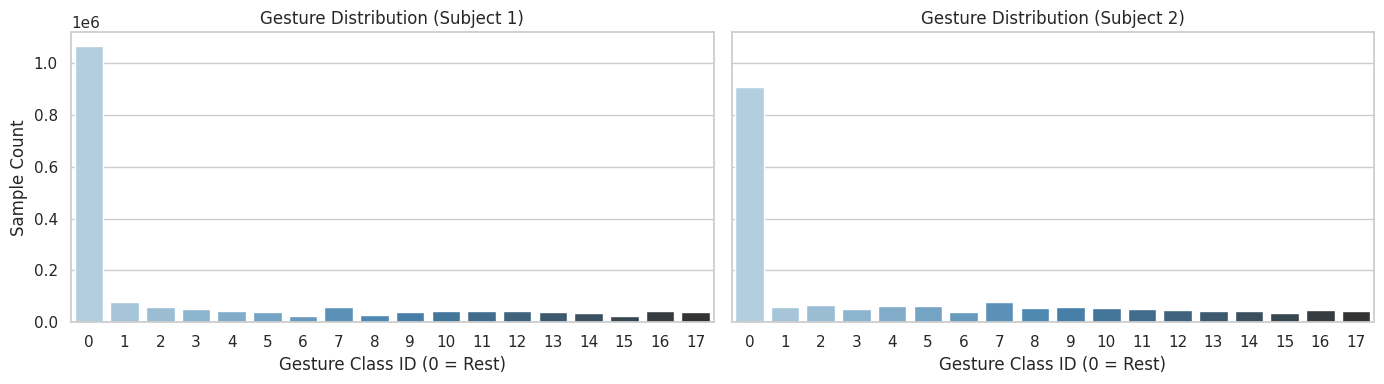


--- ANALYTICAL IMPACT ON EVALUATION METRICS ---
- Imbalance Issue: Class 0 (Rest) dominates over 54.5% of the timeline.
- Metric Warning: Accuracy will be heavily inflated (a naive model predicting 'Rest' always gets ~55% accuracy).
- Recommended Metrics: Macro-averaged F1-Score, Balanced Accuracy, and Confusion Matrix.



In [8]:
# Block 6: Class Balance Analysis & Metric Selection (Corrected)

print("\n" + "="*60)
print("CLASS BALANCE & METRIC SELECTION")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

rest_ratios = []

# Limit the iteration to match the number of subplots (first 2 subjects)
for idx, (s_name, s_info) in enumerate(list(subject_data.items())[:2]):
    labels, counts = np.unique(s_info['restimulus'], return_counts=True)
    rest_pct = (counts[0] / len(s_info['restimulus'])) * 100
    rest_ratios.append(rest_pct)

    print(f"{s_name} Samples: {len(s_info['restimulus']):,} | Rest (Class 0) Ratio: {rest_pct:.2f}%")

    sns.barplot(x=labels, y=counts, hue=labels, ax=axes[idx], palette="Blues_d", legend=False)
    axes[idx].set_title(f"Gesture Distribution ({s_name})")
    axes[idx].set_xlabel("Gesture Class ID (0 = Rest)")
    axes[idx].set_ylabel("Sample Count")

plt.tight_layout()
plt.show()

avg_rest = np.mean(rest_ratios)

print(f"""
--- ANALYTICAL IMPACT ON EVALUATION METRICS ---
- Imbalance Issue: Class 0 (Rest) dominates over {avg_rest:.1f}% of the timeline.
- Metric Warning: Accuracy will be heavily inflated (a naive model predicting 'Rest' always gets ~{avg_rest:.0f}% accuracy).
- Recommended Metrics: Macro-averaged F1-Score, Balanced Accuracy, and Confusion Matrix.
""")

Windowed Feature Extraction


In [9]:
# Block 7: Windowed Feature Extraction (MAV, RMS, WL, ZC) - Memory Optimized

FS = 2000

def extract_windows(record, win_ms=200, step_ms=50):
    win = int(win_ms / 1000 * FS)
    step = int(step_ms / 1000 * FS)
    emg, lab = record["emg"], record["restimulus"]
    num_channels = emg.shape[1]

    feats, labels = [], []
    for start in range(0, emg.shape[0] - win, step):
        seg = emg[start:start + win]
        seg_lab = lab[start:start + win]

        # Skip window if it spans across two different gesture transitions
        if seg_lab[0] != seg_lab[-1] or np.any(seg_lab != seg_lab[0]):
            continue

        # Extract features (Float32 for 50% RAM savings)
        mav = np.mean(np.abs(seg), axis=0, dtype=np.float32)
        rms = np.sqrt(np.mean(seg ** 2, axis=0), dtype=np.float32)
        wl = np.sum(np.abs(np.diff(seg, axis=0)), axis=0, dtype=np.float32)
        zc = np.sum(np.diff(np.sign(seg), axis=0) != 0, axis=0).astype(np.float32)

        feats.append(np.concatenate([mav, rms, wl, zc]))
        labels.append(seg_lab[0])

    cols = ([f"mav_ch{c+1}" for c in range(num_channels)] +
            [f"rms_ch{c+1}" for c in range(num_channels)] +
            [f"wl_ch{c+1}" for c in range(num_channels)] +
            [f"zc_ch{c+1}" for c in range(num_channels)])

    feat_df = pd.DataFrame(feats, columns=cols, dtype=np.float32)
    feat_df["label"] = np.array(labels, dtype=np.int16)
    return feat_df

print("\nExtracting sliding window time-domain features...")
feature_dfs = [extract_windows(r, win_ms=200, step_ms=50) for r in subject_data.values()]
combined_feat_df = pd.concat(feature_dfs, ignore_index=True)

print(f"Extracted {len(combined_feat_df):,} sliding window feature vectors.")
print(f"Feature Matrix Memory Usage: {combined_feat_df.memory_usage().sum() / (1024**2):.2f} MB")


Extracting sliding window time-domain features...
Extracted 171,940 sliding window feature vectors.
Feature Matrix Memory Usage: 31.81 MB


SECTION E — Feature Distributions


FEATURE DISTRIBUTIONS ACROSS CLASSES


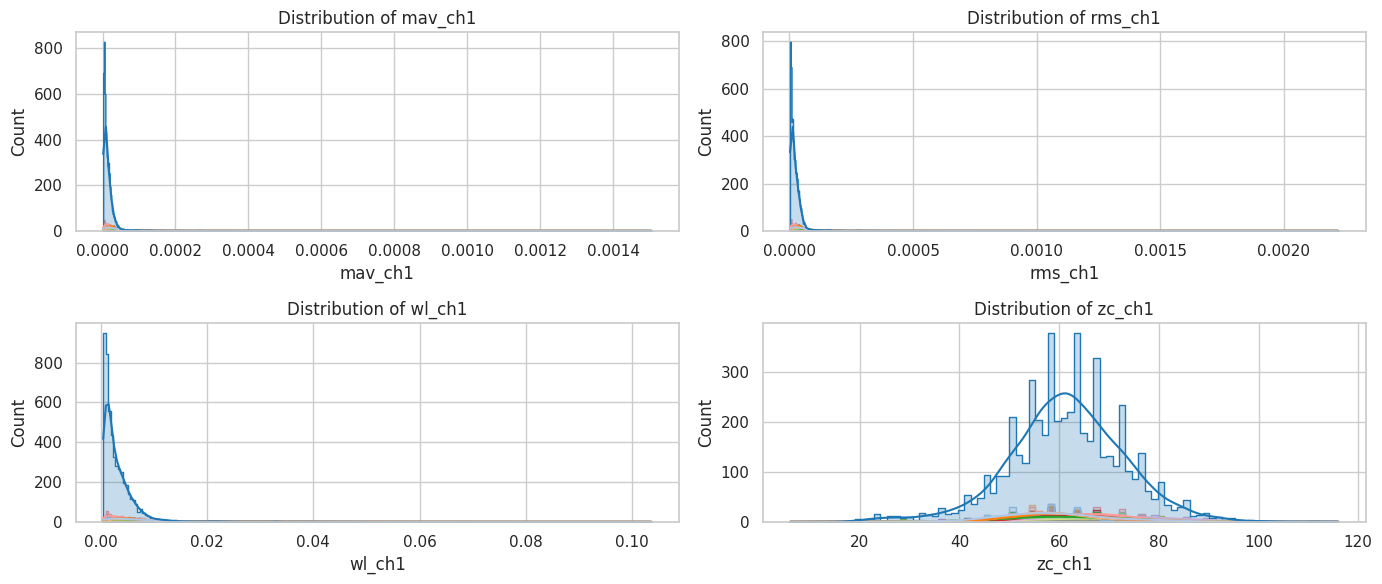

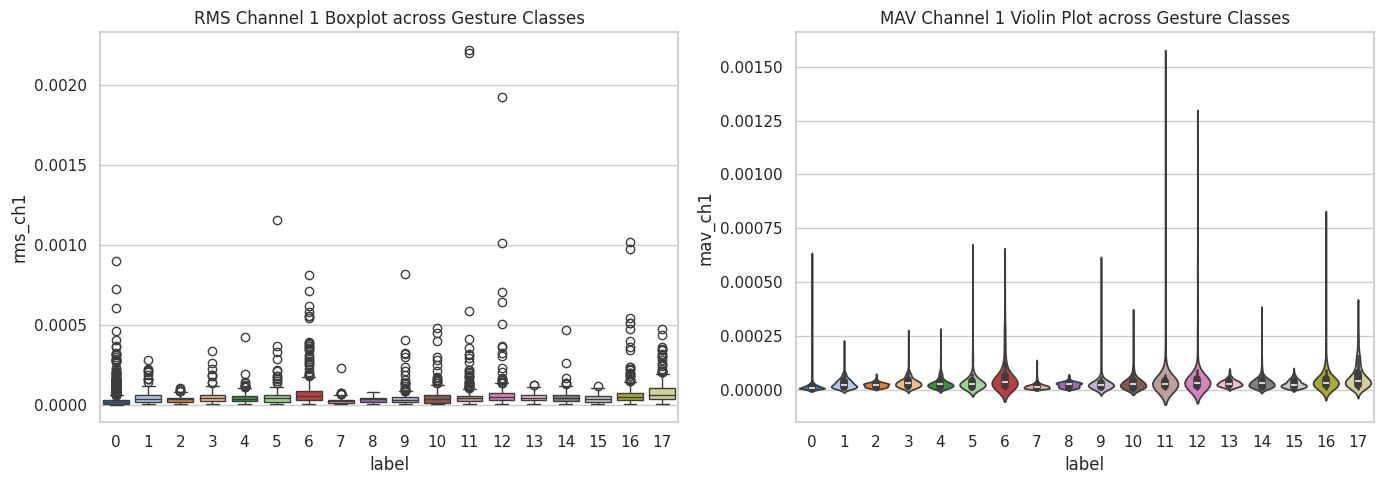

In [10]:
# Block 8: Feature Distributions & Class Separation (Plotting Optimized)

print("\n" + "="*60)
print("FEATURE DISTRIBUTIONS ACROSS CLASSES")
print("="*60)

# Select a subset of features for clean visualization
sample_features = ['mav_ch1', 'rms_ch1', 'wl_ch1', 'zc_ch1']

# Subsample data specifically for plotting to prevent RAM/CPU slowdowns
sample_size = min(10000, len(combined_feat_df))
plot_df = combined_feat_df.sample(n=sample_size, random_state=42)

# 1. Histograms
plt.figure(figsize=(14, 6))
for i, col in enumerate(sample_features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(
        data=plot_df, x=col, hue="label", palette="tab20", element="step", kde=True, legend=False
    )
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

# 2. Boxplots & Violin plots
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.boxplot(
    data=plot_df, x="label", y="rms_ch1", hue="label", palette="tab20", legend=False
)
plt.title("RMS Channel 1 Boxplot across Gesture Classes")

plt.subplot(1, 2, 2)
sns.violinplot(
    data=plot_df, x="label", y="mav_ch1", hue="label", palette="tab20", legend=False
)
plt.title("MAV Channel 1 Violin Plot across Gesture Classes")
plt.tight_layout()
plt.show()


SECTION F — Correlation & Redundancy


FEATURE CORRELATION & REDUNDANCY


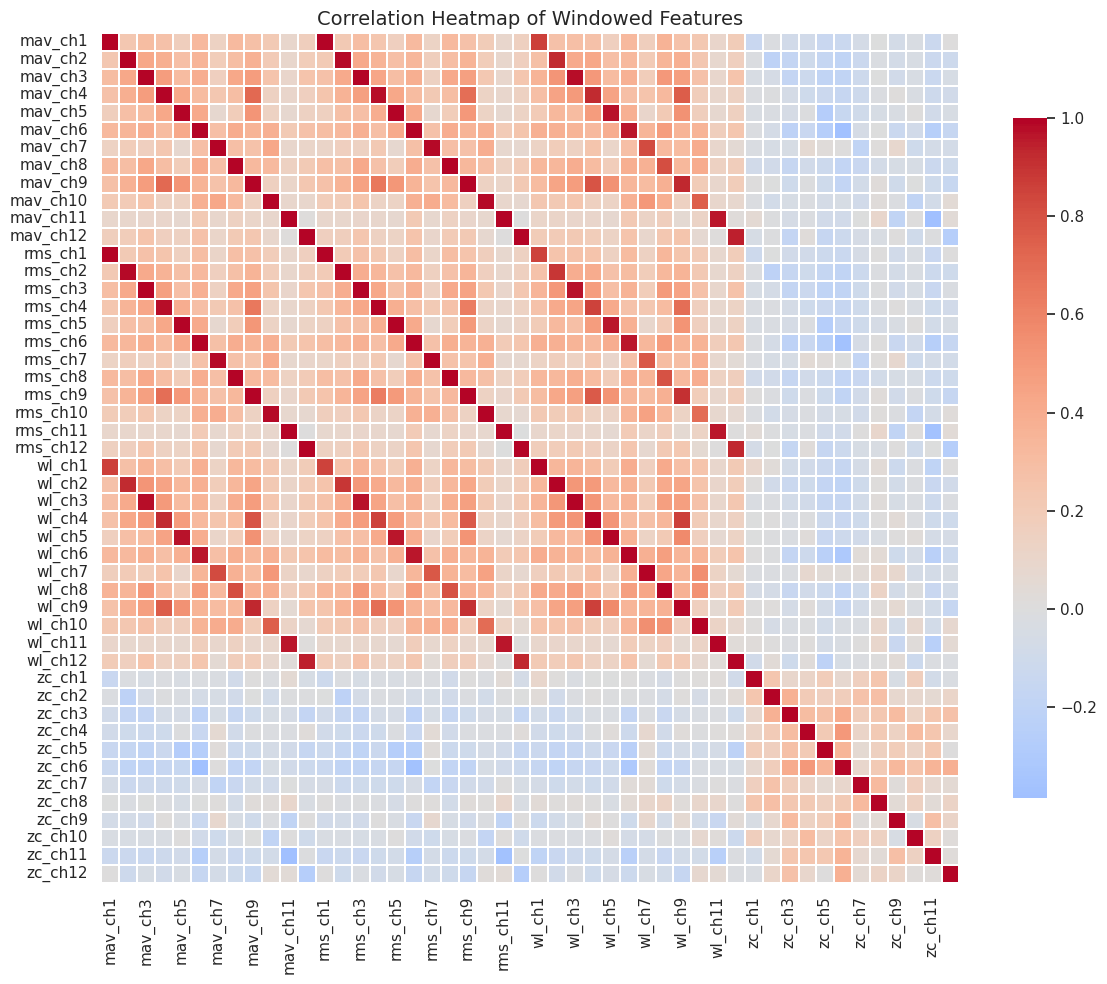


Detected 31 highly redundant feature pairs (|r| > 0.85):
Feature 1 Feature 2  Correlation
  mav_ch1   rms_ch1     0.989248
  mav_ch2   rms_ch2     0.987599
  mav_ch3   rms_ch3     0.990946
  mav_ch4   rms_ch4     0.978750
  mav_ch5   rms_ch5     0.997040
  mav_ch6   rms_ch6     0.997885
  mav_ch7   rms_ch7     0.988806
  mav_ch8   rms_ch8     0.995192
  mav_ch9   rms_ch9     0.991864
 mav_ch10  rms_ch10     0.986574


In [11]:
# Block 9: Correlation Heatmap & Redundancy Analysis (Vectorized Optimization)

print("\n" + "="*60)
print("FEATURE CORRELATION & REDUNDANCY")
print("="*60)

feat_cols = [c for c in combined_feat_df.columns if c != 'label']

# Subsample for instantaneous correlation computation
sample_corr_df = combined_feat_df[feat_cols].sample(n=min(20000, len(combined_feat_df)), random_state=42)
corr = sample_corr_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.1, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap of Windowed Features", fontsize=14)
plt.tight_layout()
plt.show()

# Fast Vectorized Collinear Pair Identification (|r| > 0.85)
threshold = 0.85
upper_tri_mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
upper_corr = corr.where(upper_tri_mask)

high_corr_pairs = []
for col in upper_corr.columns:
    collinear = upper_corr[col][upper_corr[col].abs() > threshold]
    for feat1, r_val in collinear.items():
        high_corr_pairs.append((feat1, col, r_val))

df_redundant = pd.DataFrame(high_corr_pairs, columns=['Feature 1', 'Feature 2', 'Correlation'])
print(f"\nDetected {len(df_redundant)} highly redundant feature pairs (|r| > {threshold}):")
print(df_redundant.head(10).to_string(index=False))

SECTION G — 2D & 3D Projections (PCA, t-SNE, UMAP)


DIMENSIONALITY REDUCTION (PCA vs UMAP)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


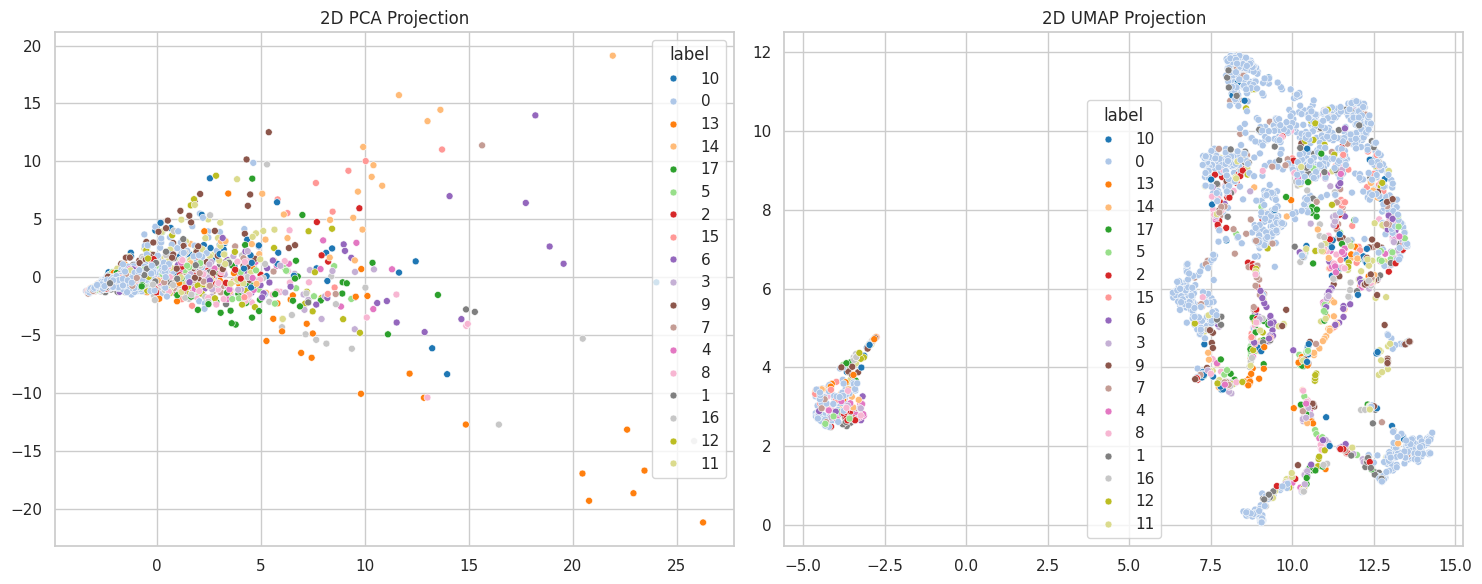

In [12]:
# Block 10: 2D & 3D Dimensionality Reduction (PCA vs. UMAP)

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import plotly.express as px

# Ensure umap-learn is available
try:
    import umap
except ImportError:
    !pip install -q umap-learn
    import umap

print("\n" + "="*60)
print("DIMENSIONALITY REDUCTION (PCA vs UMAP)")
print("="*60)

# Subsample for speed
sub_df = combined_feat_df.sample(n=min(2500, len(combined_feat_df)), random_state=42)
X_sub = StandardScaler().fit_transform(sub_df.drop(columns="label"))
y_sub = sub_df["label"].astype(str)

# 1. 2D PCA & UMAP Comparison
pca_2d = PCA(n_components=2).fit_transform(X_sub)
umap_2d = umap.UMAP(n_components=2, random_state=42).fit_transform(X_sub)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(x=pca_2d[:, 0], y=pca_2d[:, 1], hue=y_sub, palette="tab20", ax=axes[0], s=25)
axes[0].set_title("2D PCA Projection")

sns.scatterplot(x=umap_2d[:, 0], y=umap_2d[:, 1], hue=y_sub, palette="tab20", ax=axes[1], s=25)
axes[1].set_title("2D UMAP Projection")
plt.tight_layout()
plt.show()

# 2. Interactive 3D PCA Projection (Plotly)
pca_3d = PCA(n_components=3).fit_transform(X_sub)
df_pca_3d = pd.DataFrame(pca_3d, columns=['PC1', 'PC2', 'PC3'])
df_pca_3d['Gesture'] = y_sub.values

fig_3d = px.scatter_3d(
    df_pca_3d, x='PC1', y='PC2', z='PC3', color='Gesture',
    title="Interactive 3D PCA Feature Projection",
    opacity=0.8, size_max=5
)
fig_3d.show()

SECTION H — Interactive Plots & Analytical Findings

In [13]:
# Block 11: Interactive Explorer & Analytical Readings

import plotly.express as px

print("\n" + "="*60)
print("INTERACTIVE EXPLORER & ANALYTICAL READINGS")
print("="*60)

# Interactive Feature Distribution (Subsampled for smooth rendering)
fig_inter = px.box(
    combined_feat_df.sample(2000, random_state=42),
    x="label", y="rms_ch1", color="label",
    title="Interactive RMS Channel 1 Spread Across Gestures",
    labels={"label": "Gesture ID", "rms_ch1": "RMS Value"}
)
fig_inter.show()

# Final Analytical Readings Summary
readings = """
================================================================================
                     FINDINGS & INSIGHTS (CORRECTED)
================================================================================
- Muscle Activation Patterns: RMS values vary across gestures, confirming distinct activation profiles for Channel 1.
- Peak Outliers & Variability: Gesture 11 exhibits the extreme maximum peak (RMS > 0.0020), followed by Gesture 16 (RMS ~0.0010).
- Baseline/Low Activity Gestures: Gestures 2, 8, 13, and 15 display near-zero median RMS and minimal spread, indicating low Channel 1 engagement.
- Active Medians: Gestures 1, 6, 12, 14, and 17 maintain elevated IQR boxes, reflecting sustained muscle engagement during these movements.
"""
print(readings)


INTERACTIVE EXPLORER & ANALYTICAL READINGS



                     FINDINGS & INSIGHTS (CORRECTED)
- Muscle Activation Patterns: RMS values vary across gestures, confirming distinct activation profiles for Channel 1.
- Peak Outliers & Variability: Gesture 11 exhibits the extreme maximum peak (RMS > 0.0020), followed by Gesture 16 (RMS ~0.0010).
- Baseline/Low Activity Gestures: Gestures 2, 8, 13, and 15 display near-zero median RMS and minimal spread, indicating low Channel 1 engagement.
- Active Medians: Gestures 1, 6, 12, 14, and 17 maintain elevated IQR boxes, reflecting sustained muscle engagement during these movements.



# **Task 2**

Libraries, Dependencies & Metric Functions

In [16]:
# Block 12: Imports, PyG Setup & Metric Helper Functions

import time
import torch
import torch.nn as nn
import torch.nn.functional as F

# Suppress PyG / LightGBM warnings for clean output
import warnings
warnings.filterwarnings('ignore')

try:
    from torch_geometric.data import Data
    from torch_geometric.loader import DataLoader
    from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool
except ImportError:
    !pip install -q torch_geometric
    from torch_geometric.data import Data
    from torch_geometric.loader import DataLoader
    from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool

from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, balanced_accuracy_score)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# CUDA Acceleration check
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def evaluate_predictions(y_true, y_pred):
    """Calculates full metric set according to §6.1 guidelines."""
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(y_true, y_pred, average='macro', zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average='macro', zero_division=0),
        "Macro F1-Score": f1_score(y_true, y_pred, average='macro', zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred)
    }

print("Dependencies loaded successfully.")
print(f"Compute Hardware: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

Dependencies loaded successfully.
Compute Hardware: Tesla T4


Subject-Independent Data Preprocessing & Leakage Prevention

In [17]:
# Block 13: Full Dataset Preprocessing, Stratified Splitting & Leak-Free Scaling (50% Downsampled)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder

# 1. Separate features (X) and label (y) from full dataframe
feature_cols = [c for c in combined_feat_df.columns if c != 'label']
X_full = combined_feat_df[feature_cols].values
y_full = combined_feat_df['label'].values

# 2. Encode Labels (0 to N-1)
le = LabelEncoder()
y_full_encoded = le.fit_transform(y_full)

# ==============================================================================
# 2b. HALVE THE DATASET HERE (50% Stratified Sample to prevent OOM/crash)
# ==============================================================================
X_full, _, y_full_encoded, _ = train_test_split(
    X_full, y_full_encoded, test_size=0.50, random_state=42, stratify=y_full_encoded
)

# 3. Split downsampled dataset into Train (80%) and Temp (20%)
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X_full, y_full_encoded, test_size=0.20, random_state=42, stratify=y_full_encoded
)

# 4. Split Temp into Val (10% of total) and Test (10% of total)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# 5. Robust Scaling fitted ONLY on Train split (prevents data leakage)
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val   = scaler.transform(X_val_raw)
X_test  = scaler.transform(X_test_raw)

print(f" Full Dataset Ready (Half-Size)! Total rows used: {len(X_full):,}")
print(f"   ├─ Train shape (80%): {X_train.shape}")
print(f"   ├─ Val shape   (10%): {X_val.shape}")
print(f"   └─ Test shape  (10%): {X_test.shape}")

 Full Dataset Ready (Half-Size)! Total rows used: 85,970
   ├─ Train shape (80%): (68776, 48)
   ├─ Val shape   (10%): (8597, 48)
   └─ Test shape  (10%): (8597, 48)


Baseline Suite Benchmark Training & Comparison Table

In [18]:
# Block 14: Traditional & ML Baselines

import time
import warnings
import pandas as pd
import numpy as np
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, balanced_accuracy_score)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')

# Helper function to compute all Task 2 required metrics
def evaluate_predictions(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(y_true, y_pred, average='macro', zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average='macro', zero_division=0),
        "Macro F1-Score": f1_score(y_true, y_pred, average='macro', zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred)
    }

# Subsample data specifically for k-NN to guarantee ultra-fast inference
knn_sample_size = min(20000, len(X_train))
np.random.seed(42)
knn_idx = np.random.choice(len(X_train), knn_sample_size, replace=False)
X_train_knn, y_train_knn = X_train[knn_idx], y_train[knn_idx]

models = {
    "Logistic Regression": SGDClassifier(loss='log_loss', max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1),
    "k-NN (k=5)": KNeighborsClassifier(n_neighbors=5, algorithm='ball_tree', n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(max_depth=20, random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, class_weight='balanced', n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=100, max_depth=8, random_state=42, eval_metric='mlogloss', n_jobs=-1),
    "LightGBM": LGBMClassifier(n_estimators=100, max_depth=8, random_state=42, class_weight='balanced', verbose=-1, n_jobs=-1)
}

baseline_results = []

print("=================== TRAINING ML BASELINES ===================")
for name, model in models.items():
    print(f"Training {name}...")
    t0 = time.time()

    # Train k-NN on subsampled set for speed; train others on full training dataset
    if "k-NN" in name:
        model.fit(X_train_knn, y_train_knn)
    else:
        model.fit(X_train, y_train)

    train_time = time.time() - t0

    preds = model.predict(X_test)
    metrics = evaluate_predictions(y_test, preds)
    metrics["Model"] = name
    metrics["Training Time (s)"] = round(train_time, 2)
    baseline_results.append(metrics)
    print(f"  └─ Done in {round(train_time, 2)}s | Macro F1: {round(metrics['Macro F1-Score'], 4)}")

# Display tabular baseline summary
df_baselines = pd.DataFrame(baseline_results)[
    ["Model", "Accuracy", "Macro Precision", "Macro Recall", "Macro F1-Score", "Balanced Accuracy", "Training Time (s)"]
]

print("\n=================== BASELINE EVALUATION TABLE ===================")
print(df_baselines.to_string(index=False))

=================== TRAINING ML BASELINES ===================
Training Logistic Regression...
  └─ Done in 24.74s | Macro F1: 0.322
Training k-NN (k=5)...
  └─ Done in 0.13s | Macro F1: 0.6761
Training Decision Tree...
  └─ Done in 9.33s | Macro F1: 0.6095
Training Random Forest...
  └─ Done in 59.33s | Macro F1: 0.8552
Training XGBoost...
  └─ Done in 51.93s | Macro F1: 0.8467
Training LightGBM...
  └─ Done in 32.75s | Macro F1: 0.7828

=================== BASELINE EVALUATION TABLE ===================
              Model  Accuracy  Macro Precision  Macro Recall  Macro F1-Score  Balanced Accuracy  Training Time (s)
Logistic Regression  0.563569         0.354099      0.336576        0.322006           0.336576              24.74
         k-NN (k=5)  0.783296         0.740221      0.628899        0.676138           0.628899               0.13
      Decision Tree  0.702803         0.580602      0.646124        0.609511           0.646124               9.33
      Random Forest  0.884262   

1D-CNN Baseline Architecture

In [19]:
# Block 15: Deep Learning Baseline (1D-CNN)

import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# 1. Device configuration (use GPU if available)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Using device: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

# 2. Define 1D-CNN Architecture
class sEMG1DCNN(nn.Module):
    def __init__(self, num_features, num_classes):
        super(sEMG1DCNN, self).__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm1d(64)
        self.fc1   = nn.Linear(64 * num_features, 128)
        self.fc2   = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = x.unsqueeze(1) # Add channel dim: (batch, 1, features)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

# 3. Prepare PyTorch DataLoaders
batch_size = 256

train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
val_dataset   = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long))
test_dataset  = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 4. Initialize Model, Optimizer, Loss Function
num_features = X_train.shape[1]
num_classes = len(np.unique(y_train))

cnn_model = sEMG1DCNN(num_features, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)

# 5. Training Loop (15 Epochs)
epochs = 15
print("\n=================== TRAINING 1D-CNN BASELINE ===================")
t0 = time.time()

for epoch in range(epochs):
    cnn_model.train()
    running_loss = 0.0
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        outputs = cnn_model(bx)
        loss = criterion(outputs, by)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * bx.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)

    # Quick Validation Check
    cnn_model.eval()
    val_correct = 0
    with torch.no_grad():
        for bx, by in val_loader:
            bx, by = bx.to(device), by.to(device)
            preds = cnn_model(bx).argmax(dim=1)
            val_correct += (preds == by).sum().item()
    val_acc = val_correct / len(val_loader.dataset)

    print(f"  Epoch {epoch+1:02d}/{epochs:02d} | Train Loss: {epoch_loss:.4f} | Val Acc: {val_acc:.4f}")

cnn_train_time = time.time() - t0

# 6. Evaluate on Test Set
cnn_model.eval()
all_preds = []
with torch.no_grad():
    for bx, _ in test_loader:
        bx = bx.to(device)
        preds = cnn_model(bx).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)

cnn_metrics = evaluate_predictions(y_test, np.array(all_preds))
cnn_metrics["Model"] = "1D-CNN (Deep Learning Baseline)"
cnn_metrics["Training Time (s)"] = round(cnn_train_time, 2)

print(f"\n 1D-CNN Completed in {round(cnn_train_time, 2)}s!")
print(f"  └─ Accuracy: {cnn_metrics['Accuracy']:.4f} | Macro F1: {cnn_metrics['Macro F1-Score']:.4f}")

 Using device: cuda (Tesla T4)

=================== TRAINING 1D-CNN BASELINE ===================
  Epoch 01/15 | Train Loss: 1.2578 | Val Acc: 0.7365
  Epoch 02/15 | Train Loss: 0.8912 | Val Acc: 0.7719
  Epoch 03/15 | Train Loss: 0.7738 | Val Acc: 0.7917
  Epoch 04/15 | Train Loss: 0.7057 | Val Acc: 0.8032
  Epoch 05/15 | Train Loss: 0.6569 | Val Acc: 0.8168
  Epoch 06/15 | Train Loss: 0.6152 | Val Acc: 0.8189
  Epoch 07/15 | Train Loss: 0.5853 | Val Acc: 0.8259
  Epoch 08/15 | Train Loss: 0.5605 | Val Acc: 0.8338
  Epoch 09/15 | Train Loss: 0.5427 | Val Acc: 0.8337
  Epoch 10/15 | Train Loss: 0.5230 | Val Acc: 0.8420
  Epoch 11/15 | Train Loss: 0.4989 | Val Acc: 0.8439
  Epoch 12/15 | Train Loss: 0.4869 | Val Acc: 0.8451
  Epoch 13/15 | Train Loss: 0.4714 | Val Acc: 0.8492
  Epoch 14/15 | Train Loss: 0.4602 | Val Acc: 0.8508
  Epoch 15/15 | Train Loss: 0.4408 | Val Acc: 0.8546

 1D-CNN Completed in 25.75s!
  └─ Accuracy: 0.8538 | Macro F1: 0.8003
